<a href="https://colab.research.google.com/github/leman-cap13/NLP_projects/blob/main/GRU_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bitcoin

In [ ]:
!curl -L -o bitcoin-historical-datasets-2018-2024.zip\
  https://www.kaggle.com/api/v1/datasets/download/novandraanugrah/bitcoin-historical-datasets-2018-2024

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19.4M  100 19.4M    0     0  29.5M      0 --:--:-- --:--:-- --:--:-- 29.5M


In [ ]:
!unzip /content/bitcoin-historical-datasets-2018-2024.zip

Archive:  /content/bitcoin-historical-datasets-2018-2024.zip
  inflating: btc_15m_data_2018_to_2025.csv  
  inflating: btc_1d_data_2018_to_2025.csv  
  inflating: btc_1h_data_2018_to_2025.csv  
  inflating: btc_4h_data_2018_to_2025.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/btc_1d_data_2018_to_2025.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(2997, 12)
['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time', 'Quote asset volume', 'Number of trades', 'Taker buy base asset volume', 'Taker buy quote asset volume', 'Ignore']
                        Open time      Open      High       Low     Close  \
0  2018-01-01 00:00:00.000000 UTC  13715.65  13818.55  12750.00  13380.00   
1  2018-01-02 00:00:00.000000 UTC  13382.16  15473.49  12890.02  14675.11   
2  2018-01-03 00:00:00.000000 UTC  14690.00  15307.56  14150.00  14919.51   
3  2018-01-04 00:00:00.000000 UTC  14919.51  15280.00  13918.04  15059.54   
4  2018-01-05 00:00:00.000000 UTC  15059.56  17176.24  14600.00  16960.39   

         Volume                      Close time  Quote asset volume  \
0   8609.915844  2018-01-01 23:59:59.999000 UTC        1.147997e+08   
1  20078.092111  2018-01-02 23:59:59.999000 UTC        2.797171e+08   
2  15905.667639  2018-01-03 23:59:59.999000 UTC        2.361169e+08   
3  21329.649574  2018-01-04 23:59:59.999000 UTC        3.

In [ ]:
data = df[['Open time', 'Close']].copy()
data.columns = ['datetime', 'Close']
data['datetime'] = pd.to_datetime(data['datetime'], utc=True)
data = data.sort_values('datetime').reset_index(drop=True)

print(data.shape)
print(data.head())

(2997, 2)
                   datetime     Close
0 2018-01-01 00:00:00+00:00  13380.00
1 2018-01-02 00:00:00+00:00  14675.11
2 2018-01-03 00:00:00+00:00  14919.51
3 2018-01-04 00:00:00+00:00  15059.54
4 2018-01-05 00:00:00+00:00  16960.39


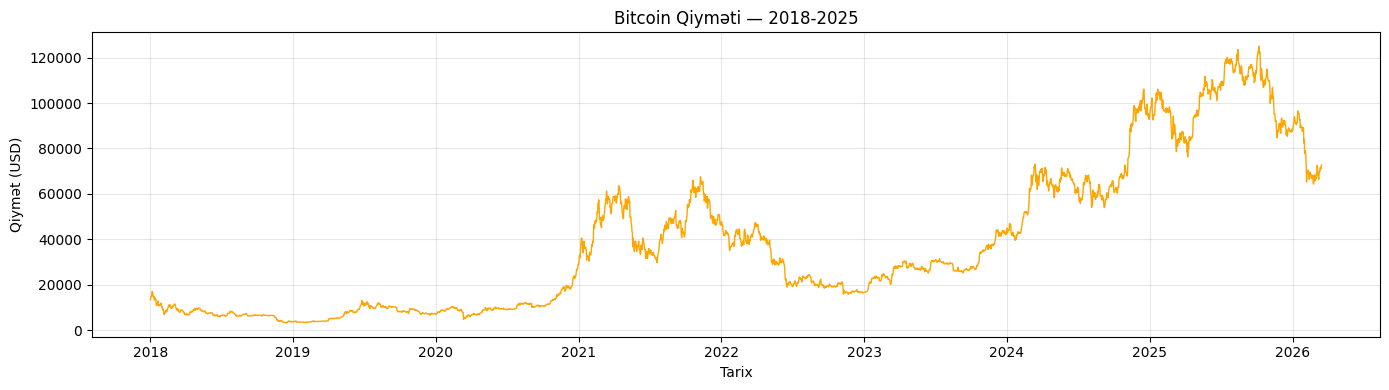

Min: 3211.72
Max: 125046.94


In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(data['datetime'], data['Close'], lw=1, color='orange')
plt.title('Bitcoin Qiyməti — 2018-2025')
plt.xlabel('Tarix')
plt.ylabel('Qiymət (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Min:', data['Close'].min())
print('Max:', data['Close'].max())

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['Close_scaled'] = scaler.fit_transform(data[['Close']])

print(data[['Close', 'Close_scaled']].head())

      Close  Close_scaled
0  13380.00      0.083459
1  14675.11      0.094089
2  14919.51      0.096095
3  15059.54      0.097245
4  16960.39      0.112846


In [ ]:
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

values = data['Close_scaled'].values
X, y = create_sequences(values, SEQ_LEN)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2937, 60)
y shape: (2937,)


In [ ]:
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape(-1, SEQ_LEN, 1)
X_test  = X_test.reshape(-1, SEQ_LEN, 1)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (2349, 60, 1)
X_test : (588, 60, 1)


In [ ]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

model     = GRUModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print('Train batch sayı:', len(train_loader))
print('Test  batch sayı:', len(test_loader))

Train batch sayı: 74
Test  batch sayı: 19


In [ ]:
EPOCHS = 50
losses = []

for epoch in range(EPOCHS):
    model.train()
    ep_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    avg = ep_loss / len(train_loader)
    losses.append(avg)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {avg:.6f}')

print('Train tamamlandı.')

Epoch 10/50  Loss: 0.000176
Epoch 20/50  Loss: 0.000142
Epoch 30/50  Loss: 0.000118
Epoch 40/50  Loss: 0.000115
Epoch 50/50  Loss: 0.000130
Train tamamlandı.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
preds = []
reals = []

with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        preds.append(pred.numpy())
        reals.append(yb.numpy())

preds = np.concatenate(preds).flatten()
reals = np.concatenate(reals).flatten()

pred = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
real = scaler.inverse_transform(reals.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(real, pred)
rmse = np.sqrt(mean_squared_error(real, pred))
mape = np.mean(np.abs((real - pred) / real)) * 100

print(f'MAE  : ${mae:,.0f}')
print(f'RMSE : ${rmse:,.0f}')
print(f'MAPE : {mape:.2f}%')

MAE  : $3,843
RMSE : $4,467
MAPE : 4.02%


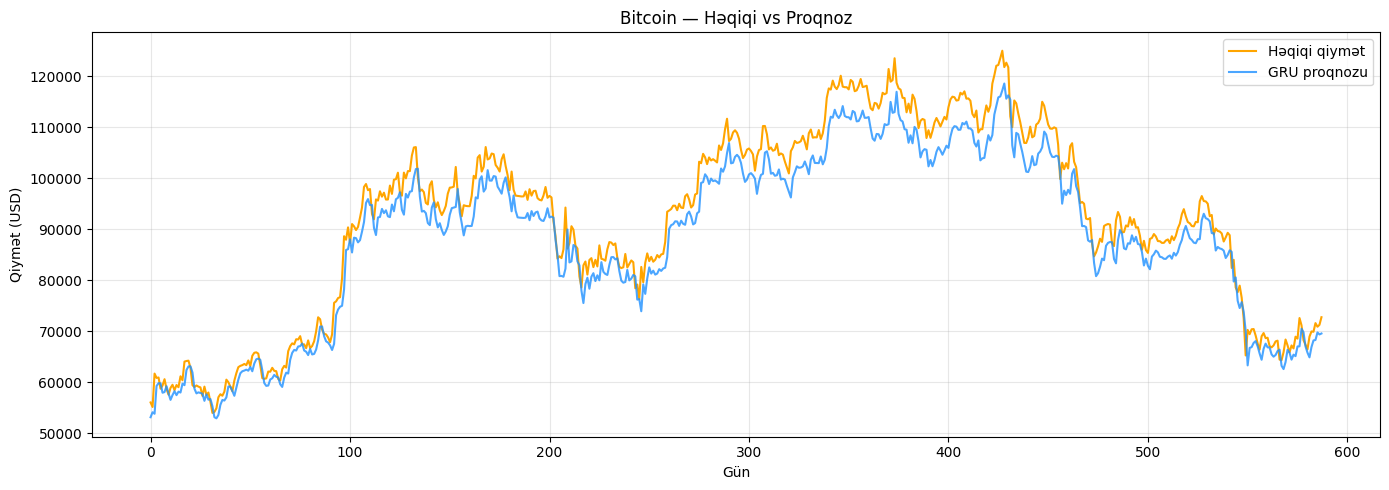

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(real, lw=1.5, color='orange', label='Həqiqi qiymət')
plt.plot(pred, lw=1.5, color='dodgerblue', label='GRU proqnozu', alpha=0.8)
plt.title('Bitcoin — Həqiqi vs Proqnoz')
plt.xlabel('Gün')
plt.ylabel('Qiymət (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
FUTURE_DAYS = 30

last_seq     = values[-SEQ_LEN:].tolist()
future_preds = []

model.eval()
with torch.no_grad():
    for _ in range(FUTURE_DAYS):
        inp  = torch.tensor(last_seq[-SEQ_LEN:], dtype=torch.float32).reshape(1, SEQ_LEN, 1)
        pred = model(inp).item()
        future_preds.append(pred)
        last_seq.append(pred)

future_prices = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
).flatten()

from datetime import timedelta
last_date    = data['datetime'].iloc[-1]
future_dates = [last_date + timedelta(days=i+1) for i in range(FUTURE_DAYS)]

print('Növbəti 30 günün proqnozu:')
for d, p in zip(future_dates, future_prices):
    print(f'{d.date()}  →  ${p:,.0f}')

Növbəti 30 günün proqnozu:
2026-03-17  →  $70,901
2026-03-18  →  $69,462
2026-03-19  →  $67,924
2026-03-20  →  $66,381
2026-03-21  →  $64,816
2026-03-22  →  $63,252
2026-03-23  →  $61,698
2026-03-24  →  $60,164
2026-03-25  →  $58,656
2026-03-26  →  $57,181
2026-03-27  →  $55,744
2026-03-28  →  $54,348
2026-03-29  →  $52,998
2026-03-30  →  $51,696
2026-03-31  →  $50,446
2026-04-01  →  $49,248
2026-04-02  →  $48,104
2026-04-03  →  $47,016
2026-04-04  →  $45,984
2026-04-05  →  $45,006
2026-04-06  →  $44,083
2026-04-07  →  $43,214
2026-04-08  →  $42,397
2026-04-09  →  $41,630
2026-04-10  →  $40,912
2026-04-11  →  $40,239
2026-04-12  →  $39,611
2026-04-13  →  $39,024
2026-04-14  →  $38,476
2026-04-15  →  $37,965


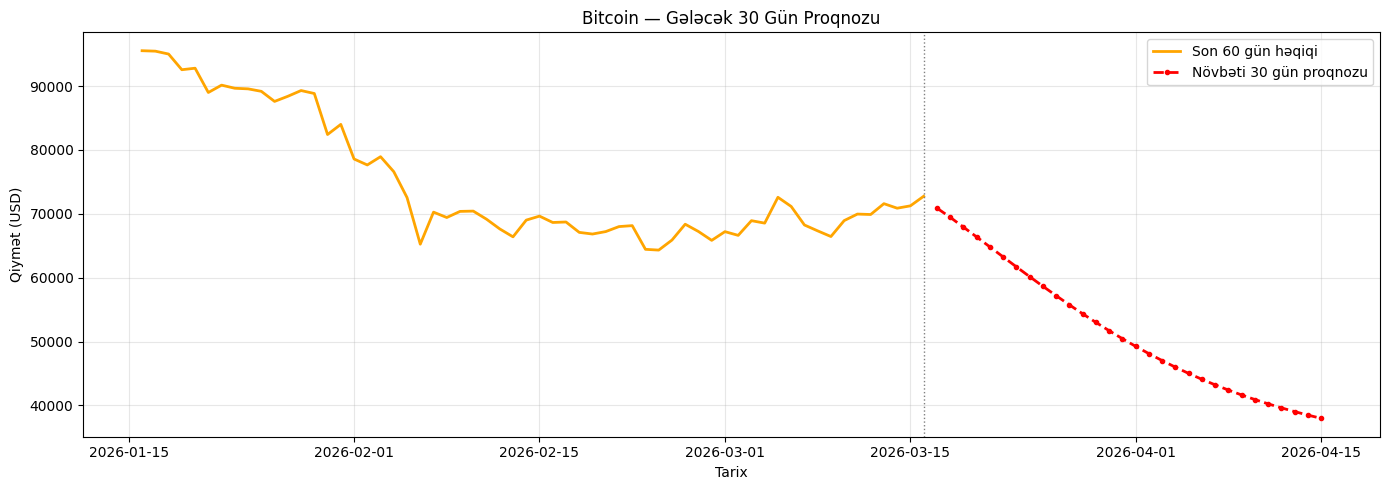

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(data['datetime'].iloc[-60:],
         data['Close'].iloc[-60:],
         lw=2, color='orange', label='Son 60 gün həqiqi')
plt.plot(future_dates, future_prices,
         lw=2, color='red', linestyle='--',
         label='Növbəti 30 gün proqnozu', marker='o', markersize=3)
plt.axvline(x=last_date, color='gray', lw=1, linestyle=':')
plt.title('Bitcoin — Gələcək 30 Gün Proqnozu')
plt.xlabel('Tarix')
plt.ylabel('Qiymət (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
!pip install yfinance -q
import yfinance as yf

btc = yf.download('BTC-USD', start='2026-03-16', end='2026-05-18', progress=False)
print(btc['Close'])

/tmp/ipykernel_492/1431694068.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2026-03-16', end='2026-05-18', progress=False)


Ticker           BTC-USD
Date                    
2026-03-16  74861.085938
2026-03-17  73922.476562
2026-03-18  71245.578125
2026-03-19  69912.789062
2026-03-20  70522.585938
...                  ...
2026-05-13  79277.117188
2026-05-14  81051.250000
2026-05-15  79065.679688
2026-05-16  78131.437500
2026-05-17  77429.351562

[63 rows x 1 columns]


In [ ]:
real_dates_list = list(real_dates[:5])
real_btc_list   = list(real_btc[:5])

model_pred = {
    '2026-03-16': 70901,
    '2026-03-17': 69462,
    '2026-03-18': 67924,
    '2026-03-19': 66381,
    '2026-03-20': 64816,
}

print('Tarix         Həqiqi     Model      Fərq')
print('-' * 48)
for date, real in zip(real_dates_list, real_btc_list):
    key = str(date.date())
    if key in model_pred:
        model = model_pred[key]
        ferg  = real - model
        print(f'{key}   ${real:,.0f}    ${model:,.0f}    ${ferg:+,.0f}')

Tarix         Həqiqi     Model      Fərq
------------------------------------------------
2026-03-16   $74,861    $70,901    $+3,960
2026-03-17   $73,922    $69,462    $+4,460
2026-03-18   $71,246    $67,924    $+3,322
2026-03-19   $69,913    $66,381    $+3,532
2026-03-20   $70,523    $64,816    $+5,707


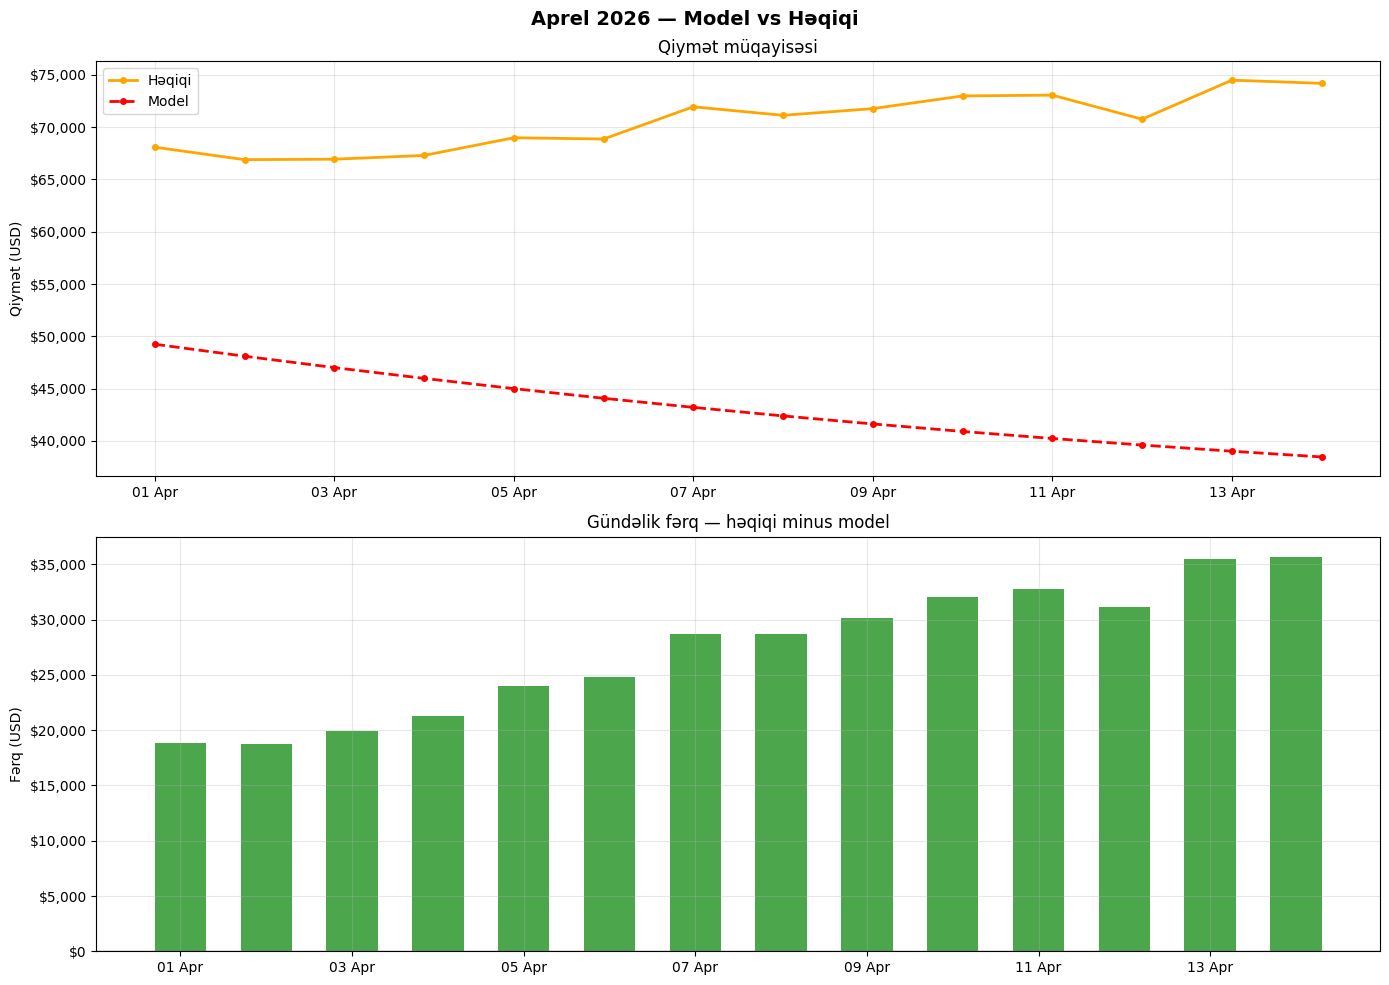

In [ ]:
btc_april = btc[(btc.index >= '2026-04-01') & (btc.index <= '2026-04-14')]

april_real_dates  = list(btc_april.index)
april_real_prices = btc_april['Close'].values.flatten()

april_model_dates = [
    datetime(2026,4,1),  datetime(2026,4,2),  datetime(2026,4,3),
    datetime(2026,4,4),  datetime(2026,4,5),  datetime(2026,4,6),
    datetime(2026,4,7),  datetime(2026,4,8),  datetime(2026,4,9),
    datetime(2026,4,10), datetime(2026,4,11), datetime(2026,4,12),
    datetime(2026,4,13), datetime(2026,4,14)
]

april_model_prices = [
    49248, 48104, 47016, 45984, 45006,
    44083, 43214, 42397, 41630, 40912,
    40239, 39611, 39024, 38476
]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Aprel 2026 — Model vs Həqiqi', fontsize=14, fontweight='bold')

# ── Plot 1: Qiymət ──
axes[0].plot(april_real_dates,  april_real_prices,  lw=2, color='orange', marker='o', markersize=4, label='Həqiqi')
axes[0].plot(april_model_dates, april_model_prices, lw=2, color='red',    marker='o', markersize=4, label='Model', linestyle='--')
axes[0].set_title('Qiymət müqayisəsi')
axes[0].set_ylabel('Qiymət (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# ── Plot 2: Fərq ──
ferg   = [april_real_prices[i] - april_model_prices[i] for i in range(len(april_model_dates))]
colors = ['green' if f > 0 else 'red' for f in ferg]
axes[1].bar(april_model_dates, ferg, color=colors, alpha=0.7, width=0.6)
axes[1].axhline(y=0, color='gray', lw=1)
axes[1].set_title('Gündəlik fərq — həqiqi minus model')
axes[1].set_ylabel('Fərq (USD)')
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.show()

# Energy Consumption

In [ ]:
!curl -L -o energy-consumption-time-series-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/vitthalmadane/energy-consumption-time-series-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 35598  100 35598    0     0  67599      0 --:--:-- --:--:-- --:--:-- 67599


In [ ]:
!unzip /content/energy-consumption-time-series-dataset.zip

Archive:  /content/energy-consumption-time-series-dataset.zip
  inflating: KwhConsumptionBlower78_1.csv  
  inflating: KwhConsumptionBlower78_2.csv  
  inflating: KwhConsumptionBlower78_3.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/KwhConsumptionBlower78_1.csv")
df

,Unnamed: 0,TxnDate,TxnTime,Consumption
0,76229,01 Jan 2022,16:55:52,1.010
1,76258,01 Jan 2022,21:45:29,0.908
2,76287,01 Jan 2022,12:24:52,0.926
3,76316,01 Jan 2022,04:07:36,0.928
4,76345,01 Jan 2022,06:52:25,0.916
...,...,...,...,...
1223,97922,20 Jan 2022,21:43:55,5.128
1224,97951,20 Jan 2022,09:43:03,5.924
1225,97980,20 Jan 2022,03:06:05,4.664
1226,98009,20 Jan 2022,06:16:38,3.474


In [ ]:
df1=pd.read_csv("/content/KwhConsumptionBlower78_2.csv")
df1

,Unnamed: 0,TxnDate,TxnTime,Consumption
0,0,21 Jan 2022,01:57:23,4.632
1,1,21 Jan 2022,06:15:59,6.080
2,2,21 Jan 2022,13:11:00,3.194
3,3,21 Jan 2022,15:22:43,2.038
4,4,21 Jan 2022,22:01:21,7.428
...,...,...,...,...
625,625,31 Jan 2022,10:16:51,2.834
626,626,31 Jan 2022,18:37:47,4.124
627,627,31 Jan 2022,13:47:09,4.582
628,628,31 Jan 2022,16:13:21,1.006


In [ ]:
df2=pd.read_csv("/content/KwhConsumptionBlower78_3.csv")
df2

,Unnamed: 0,TxnDate,TxnTime,Consumption
0,0,01 Feb 2022,14:41:48,1.016
1,1,01 Feb 2022,17:28:44,0.928
2,2,01 Feb 2022,19:51:07,0.988
3,3,01 Feb 2022,07:26:39,1.126
4,4,01 Feb 2022,05:20:47,0.886
...,...,...,...,...
1743,1743,28 Feb 2022,22:01:52,1.020
1744,1744,28 Feb 2022,08:54:15,0.948
1745,1745,28 Feb 2022,06:26:48,0.912
1746,1746,28 Feb 2022,03:21:12,1.064


In [ ]:
data=pd.concat([df, df1, df2], ignore_index=True)
data

,Unnamed: 0,TxnDate,TxnTime,Consumption
0,76229,01 Jan 2022,16:55:52,1.010
1,76258,01 Jan 2022,21:45:29,0.908
2,76287,01 Jan 2022,12:24:52,0.926
3,76316,01 Jan 2022,04:07:36,0.928
4,76345,01 Jan 2022,06:52:25,0.916
...,...,...,...,...
3601,1743,28 Feb 2022,22:01:52,1.020
3602,1744,28 Feb 2022,08:54:15,0.948
3603,1745,28 Feb 2022,06:26:48,0.912
3604,1746,28 Feb 2022,03:21:12,1.064


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
print(data.shape)
print(data.dtypes)
print(data.head(10))

(3606, 4)
Unnamed: 0       int64
TxnDate         object
TxnTime         object
Consumption    float64
dtype: object
   Unnamed: 0      TxnDate   TxnTime  Consumption
0       76229  01 Jan 2022  16:55:52        1.010
1       76258  01 Jan 2022  21:45:29        0.908
2       76287  01 Jan 2022  12:24:52        0.926
3       76316  01 Jan 2022  04:07:36        0.928
4       76345  01 Jan 2022  06:52:25        0.916
5       76374  01 Jan 2022  10:20:09        0.972
6       76403  01 Jan 2022  15:32:01        0.878
7       76432  01 Jan 2022  19:23:47        1.902
8       76461  01 Jan 2022  11:19:47        0.900
9       76490  01 Jan 2022  14:52:01        0.928


In [ ]:
data = data.drop(columns=['Unnamed: 0'])

data['datetime'] = pd.to_datetime(data['TxnDate'] + ' ' + data['TxnTime'], dayfirst=True)

data = data.drop(columns=['TxnDate', 'TxnTime'])

data = data.sort_values('datetime').reset_index(drop=True)

print(data.head(10))
print(data.shape)

   Consumption            datetime
0        1.030 2022-01-01 00:22:28
1        0.904 2022-01-01 00:42:33
2        0.904 2022-01-01 01:01:51
3        1.850 2022-01-01 01:41:48
4        1.878 2022-01-01 02:22:52
5        1.092 2022-01-01 02:47:00
6        0.924 2022-01-01 03:06:30
7        0.944 2022-01-01 03:27:40
8        0.920 2022-01-01 03:47:47
9        0.928 2022-01-01 04:07:36
(3606, 2)


In [ ]:
data

,Consumption,datetime
0,1.030,2022-01-01 00:22:28
1,0.904,2022-01-01 00:42:33
2,0.904,2022-01-01 01:01:51
3,1.850,2022-01-01 01:41:48
4,1.878,2022-01-01 02:22:52
...,...,...
3601,1.152,2022-02-28 22:25:43
3602,0.888,2022-02-28 22:44:37
3603,1.064,2022-02-28 23:07:15
3604,1.036,2022-02-28 23:29:13


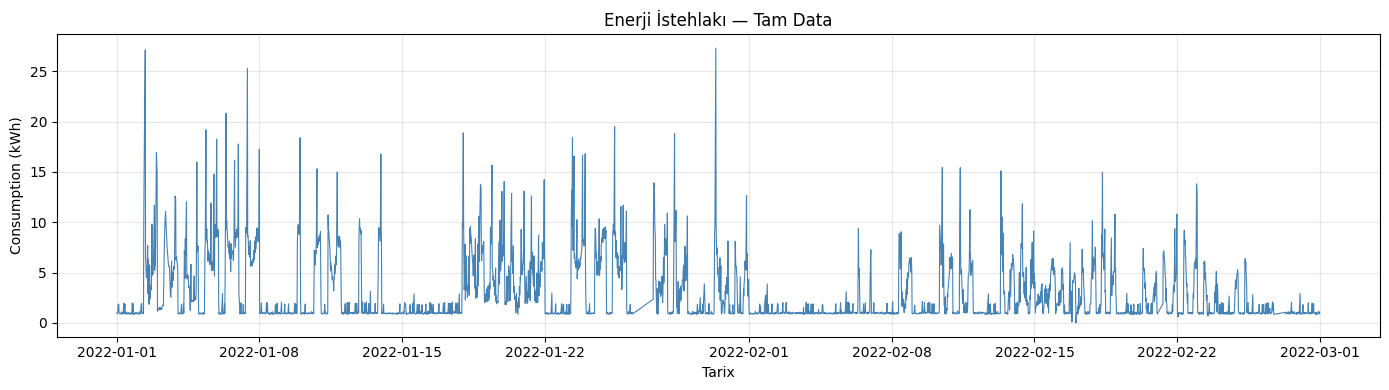

Min: 0.0
Max: 27.284
Ortalama: 2.782


In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(data['datetime'], data['Consumption'], lw=0.8, color='steelblue')
plt.title('Enerji İstehlakı — Tam Data')
plt.xlabel('Tarix')
plt.ylabel('Consumption (kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Min:', data['Consumption'].min())
print('Max:', data['Consumption'].max())
print('Ortalama:', data['Consumption'].mean().round(3))

In [ ]:
print('Sıfır dəyərlərin sayı:', (data['Consumption'] == 0).sum())
print('0.1-dən az olanlar   :', (data['Consumption'] < 0.1).sum())

Sıfır dəyərlərin sayı: 1
0.1-dən az olanlar   : 2


In [ ]:
data = data[data['Consumption'] >= 0.1].reset_index(drop=True)
print('Yeni sətir sayı:', len(data))

Yeni sətir sayı: 3604


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['Consumption_scaled'] = scaler.fit_transform(data[['Consumption']])

print(data[['Consumption', 'Consumption_scaled']].head(10))

   Consumption  Consumption_scaled
0        1.030            0.030502
1        0.904            0.025849
2        0.904            0.025849
3        1.850            0.060783
4        1.878            0.061817
5        1.092            0.032792
6        0.924            0.026588
7        0.944            0.027326
8        0.920            0.026440
9        0.928            0.026736


In [ ]:
SEQ_LEN = 48

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

values = data['Consumption_scaled'].values

X, y = create_sequences(values, SEQ_LEN)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (3556, 48)
y shape: (3556,)


In [ ]:
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape(-1, SEQ_LEN, 1)
X_test  = X_test.reshape(-1, SEQ_LEN, 1)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (2844, 48, 1)
X_test : (712, 48, 1)
y_train: (2844,)
y_test : (712,)


In [ ]:
print('X_train ilk nümunə:')
print(X_train[0].flatten())
print('Cavabı (y_train[0]):', y_train[0])

X_train ilk nümunə:
[0.03050222 0.02584934 0.02584934 0.06078287 0.06181684 0.03279173
 0.02658789 0.02732644 0.02644018 0.0267356  0.02732644 0.02555391
 0.02680945 0.03301329 0.02570162 0.0267356  0.02806499 0.02629247
 0.03013294 0.02644018 0.06491876 0.0274003  0.02644018 0.06189069
 0.02636632 0.02836041 0.02555391 0.02725258 0.02570162 0.03271787
 0.02850812 0.02666174 0.02584934 0.02776957 0.02806499 0.03131462
 0.02570162 0.02836041 0.0267356  0.02592319 0.02488922 0.02858198
 0.02481536 0.02703102 0.02976366 0.03124077 0.02651403 0.06558346]
Cavabı (y_train[0]): 0.024593796159527326


In [ ]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

model = GRUModel()
print(model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('X_train_t:', X_train_t.shape)
print('y_train_t:', y_train_t.shape)

X_train_t: torch.Size([2844, 48, 1])
y_train_t: torch.Size([2844, 1])


In [ ]:
EPOCHS     = 100
BATCH_SIZE = 32
losses     = []

for epoch in range(EPOCHS):
    model.train()
    perm    = torch.randperm(len(X_train_t))
    ep_loss = 0
    batches = 0

    for i in range(0, len(X_train_t), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        xb  = X_train_t[idx]
        yb  = y_train_t[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        ep_loss += loss.item()
        batches += 1

    avg = ep_loss / batches
    losses.append(avg)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {avg:.6f}')

print('Train tamamlandı.')

Epoch 10/100  Loss: 0.004836
Epoch 20/100  Loss: 0.004340
Epoch 30/100  Loss: 0.004221
Epoch 40/100  Loss: 0.004067
Epoch 50/100  Loss: 0.003882
Epoch 60/100  Loss: 0.003812
Epoch 70/100  Loss: 0.003878
Epoch 80/100  Loss: 0.003767
Epoch 90/100  Loss: 0.003876
Epoch 100/100  Loss: 0.003636
Train tamamlandı.


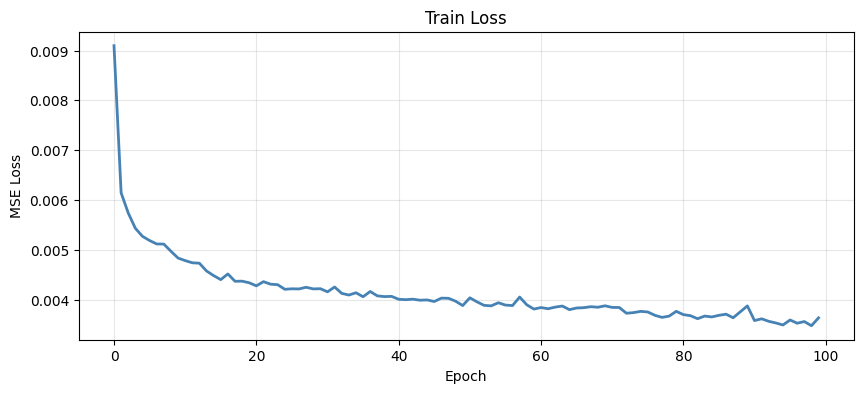

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(losses, lw=2, color='steelblue')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).squeeze().numpy()

pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

print('İlk 10 həqiqi :', real[:10].round(3))
print('İlk 10 proqnoz:', pred[:10].round(3))

İlk 10 həqiqi : [0.878 0.946 0.9   1.66  0.94  1.518 3.446 1.504 1.398 1.76 ]
İlk 10 proqnoz: [1.06  0.828 0.856 0.851 1.77  0.958 1.601 3.939 1.421 1.047]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(real, pred)
rmse = np.sqrt(mean_squared_error(real, pred))
mape = np.mean(np.abs((real - pred) / real)) * 100

print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'MAPE : {mape:.2f}%')

MAE  : 0.6391
RMSE : 1.2005
MAPE : 31.81%


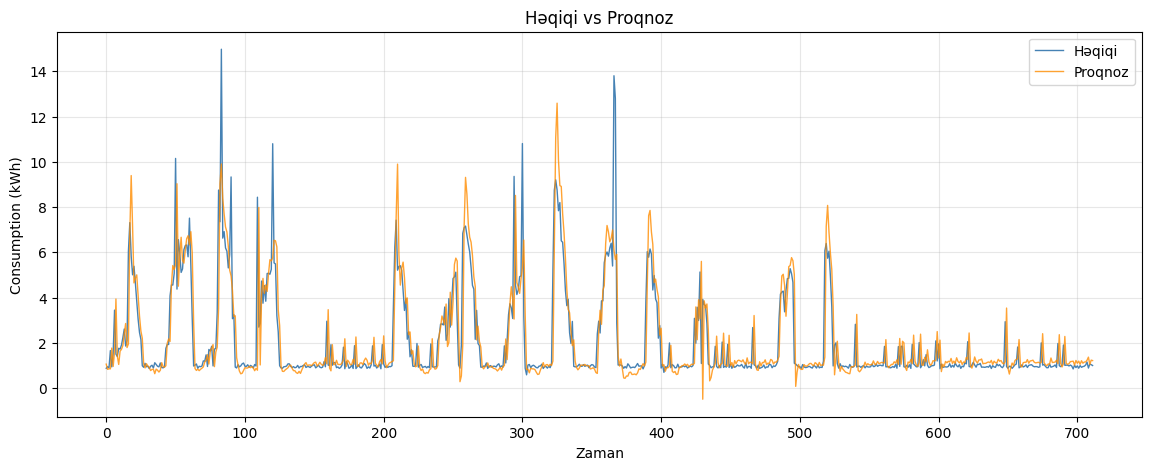

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(real, lw=1, color='steelblue', label='Həqiqi')
plt.plot(pred, lw=1, color='darkorange', label='Proqnoz', alpha=0.8)
plt.title('Həqiqi vs Proqnoz')
plt.xlabel('Zaman')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#a

#Bitcoin

In [ ]:
!curl -L -o bitcoin-historical-datasets-2018-2024.zip\
  https://www.kaggle.com/api/v1/datasets/download/novandraanugrah/bitcoin-historical-datasets-2018-2024

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19.4M  100 19.4M    0     0  29.5M      0 --:--:-- --:--:-- --:--:-- 29.5M


In [ ]:
!unzip /content/bitcoin-historical-datasets-2018-2024.zip

Archive:  /content/bitcoin-historical-datasets-2018-2024.zip
  inflating: btc_15m_data_2018_to_2025.csv  
  inflating: btc_1d_data_2018_to_2025.csv  
  inflating: btc_1h_data_2018_to_2025.csv  
  inflating: btc_4h_data_2018_to_2025.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/btc_1d_data_2018_to_2025.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(2997, 12)
['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time', 'Quote asset volume', 'Number of trades', 'Taker buy base asset volume', 'Taker buy quote asset volume', 'Ignore']
                        Open time      Open      High       Low     Close  \
0  2018-01-01 00:00:00.000000 UTC  13715.65  13818.55  12750.00  13380.00   
1  2018-01-02 00:00:00.000000 UTC  13382.16  15473.49  12890.02  14675.11   
2  2018-01-03 00:00:00.000000 UTC  14690.00  15307.56  14150.00  14919.51   
3  2018-01-04 00:00:00.000000 UTC  14919.51  15280.00  13918.04  15059.54   
4  2018-01-05 00:00:00.000000 UTC  15059.56  17176.24  14600.00  16960.39   

         Volume                      Close time  Quote asset volume  \
0   8609.915844  2018-01-01 23:59:59.999000 UTC        1.147997e+08   
1  20078.092111  2018-01-02 23:59:59.999000 UTC        2.797171e+08   
2  15905.667639  2018-01-03 23:59:59.999000 UTC        2.361169e+08   
3  21329.649574  2018-01-04 23:59:59.999000 UTC        3.

In [ ]:
features = [
    'Open', 'High', 'Low', 'Close',
    'Volume', 'Number of trades',
    'Taker buy base asset volume'
]

data = df[['Open time'] + features].copy()
data.rename(columns={'Open time': 'datetime'}, inplace=True)

data['datetime'] = pd.to_datetime(data['datetime'], utc=True)
data = data.sort_values('datetime').reset_index(drop=True)

In [ ]:
# data = df[['Open time', 'Close']].copy()
# data.columns = ['datetime', 'Close']
# data['datetime'] = pd.to_datetime(data['datetime'], utc=True)
# data = data.sort_values('datetime').reset_index(drop=True)

print(data.shape)
print(data.head())

(2997, 2)
                   datetime     Close
0 2018-01-01 00:00:00+00:00  13380.00
1 2018-01-02 00:00:00+00:00  14675.11
2 2018-01-03 00:00:00+00:00  14919.51
3 2018-01-04 00:00:00+00:00  15059.54
4 2018-01-05 00:00:00+00:00  16960.39


In [ ]:
data['buy_ratio'] = data['Taker buy base asset volume'] / data['Volume']
data = data.dropna().reset_index(drop=True)

In [ ]:
features = [
    'Open', 'High', 'Low', 'Close',
    'Volume', 'Number of trades',
    'buy_ratio'
]

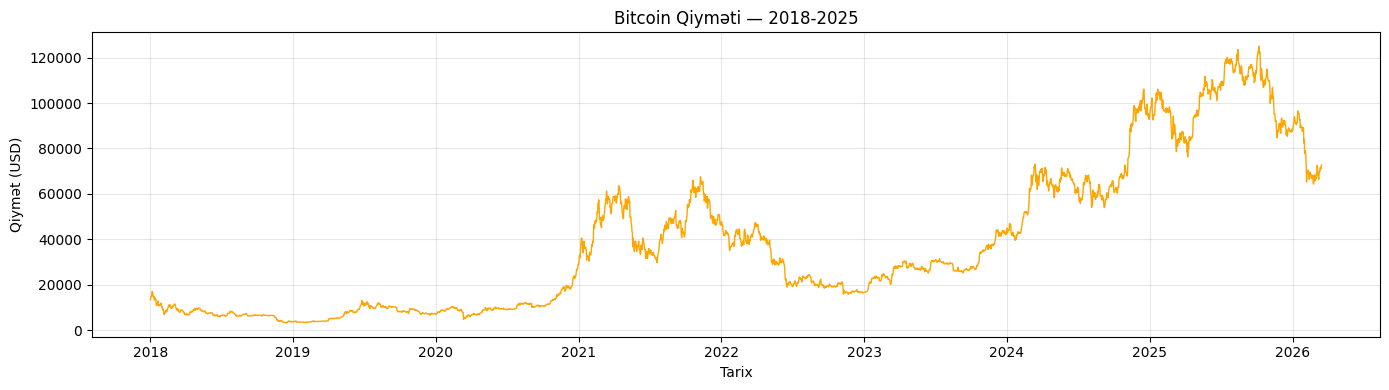

Min: 3211.72
Max: 125046.94


In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(data['datetime'], data['Close'], lw=1, color='orange')
plt.title('Bitcoin Qiyməti — 2018-2025')
plt.xlabel('Tarix')
plt.ylabel('Qiymət (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Min:', data['Close'].min())
print('Max:', data['Close'].max())

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

split_idx = int(len(data) * 0.8)

train_data = data.iloc[:split_idx]
test_data  = data.iloc[split_idx:]

scaler.fit(train_data[features])

train_scaled = scaler.transform(train_data[features])
test_scaled  = scaler.transform(test_data[features])

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# data['Close_scaled'] = scaler.fit_transform(data[['Close']])

# print(data[['Close', 'Close_scaled']].head())

      Close  Close_scaled
0  13380.00      0.083459
1  14675.11      0.094089
2  14919.51      0.096095
3  15059.54      0.097245
4  16960.39      0.112846


In [ ]:
# SEQ_LEN = 60

# def create_sequences(data, seq_len):
#     X, y = [], []
#     for i in range(len(data) - seq_len):
#         X.append(data[i : i + seq_len])
#         y.append(data[i + seq_len])
#     return np.array(X), np.array(y)

# values = data['Close_scaled'].values
# X, y = create_sequences(values, SEQ_LEN)

# print('X shape:', X.shape)
# print('y shape:', y.shape)

X shape: (2937, 60)
y shape: (2937,)


In [ ]:
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][3])  # Close index
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN)

In [ ]:
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape(-1, SEQ_LEN, 1)
X_test  = X_test.reshape(-1, SEQ_LEN, 1)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (2349, 60, 1)
X_test : (588, 60, 1)


In [ ]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(
            input_size=7,   # 🔥 dəyişdi
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

model     = GRUModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print('Train batch sayı:', len(train_loader))
print('Test  batch sayı:', len(test_loader))

Train batch sayı: 74
Test  batch sayı: 19


In [ ]:
EPOCHS = 50
losses = []

for epoch in range(EPOCHS):
    model.train()
    ep_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    avg = ep_loss / len(train_loader)
    losses.append(avg)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}  Loss: {avg:.6f}')

print('Train tamamlandı.')

Epoch 10/50  Loss: 0.000176
Epoch 20/50  Loss: 0.000142
Epoch 30/50  Loss: 0.000118
Epoch 40/50  Loss: 0.000115
Epoch 50/50  Loss: 0.000130
Train tamamlandı.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import torch

model.eval()

preds = []
reals = []

with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)

        preds.append(pred.cpu().numpy())
        reals.append(yb.cpu().numpy())

preds = np.concatenate(preds).flatten()
reals = np.concatenate(reals).flatten()


# ==============================
# 🔥 CLOSE-INVERSE FUNCTION
# ==============================
def inverse_close(scaled_values, scaler, feature_index=3):
    dummy = np.zeros((len(scaled_values), scaler.n_features_in_))
    dummy[:, feature_index] = scaled_values
    return scaler.inverse_transform(dummy)[:, feature_index]


# ==============================
# 🔥 BACK TO REAL PRICE
# ==============================
pred = inverse_close(preds, scaler)
real = inverse_close(reals, scaler)


# ==============================
# 🔥 METRICS
# ==============================
mae  = mean_absolute_error(real, pred)
rmse = np.sqrt(mean_squared_error(real, pred))
mape = np.mean(np.abs((real - pred) / real)) * 100


print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.2f}%")

MAE  : $3,843
RMSE : $4,467
MAPE : 4.02%


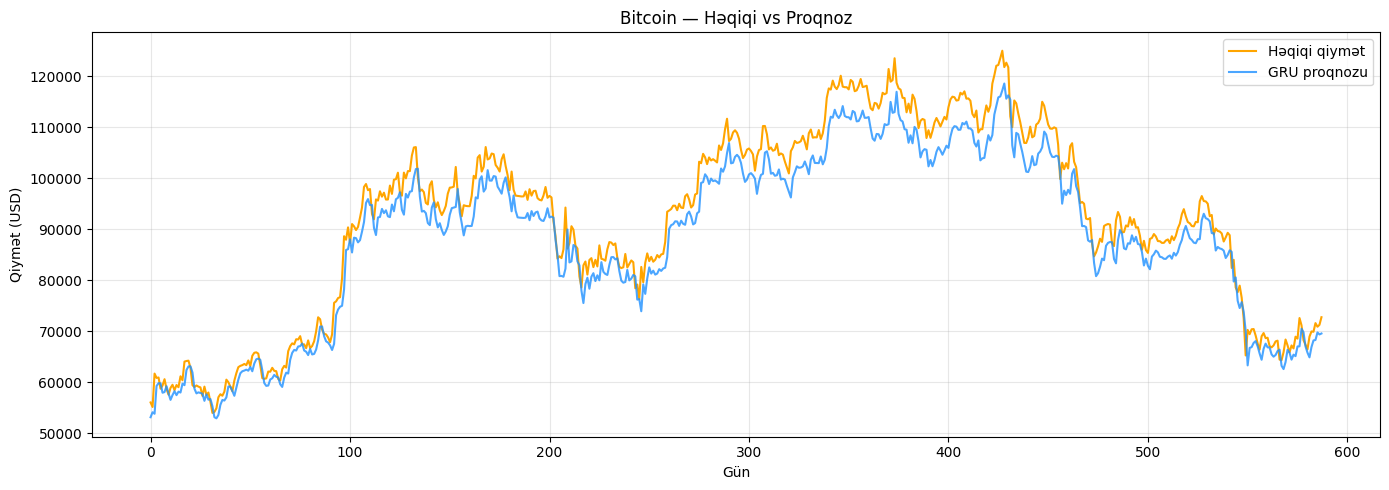

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(real, lw=1.5, color='orange', label='Həqiqi qiymət')
plt.plot(pred, lw=1.5, color='dodgerblue', label='GRU proqnozu', alpha=0.8)
plt.title('Bitcoin — Həqiqi vs Proqnoz')
plt.xlabel('Gün')
plt.ylabel('Qiymət (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch

model.eval()

# =========================
# SON WINDOW (son 60 gün)
# =========================
last_sequence = test_scaled[-SEQ_LEN:]  # shape: (60, features)

current_input = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0)

future_preds = []
FUTURE_DAYS = 30  # dəyişə bilərsən

with torch.no_grad():
    for _ in range(FUTURE_DAYS):
        pred = model(current_input)   # (1,1)
        pred_value = pred.item()

        future_preds.append(pred_value)

        # =========================
        # yeni window yarat (sliding)
        # =========================
        new_row = np.zeros((1, current_input.shape[2]))
        new_row[0, 3] = pred_value  # 3 = Close index

        current_input = current_input.squeeze(0).numpy()
        current_input = np.vstack([current_input[1:], new_row])

        current_input = torch.tensor(current_input, dtype=torch.float32).unsqueeze(0)


# =========================
# BACK TO REAL PRICE
# =========================
def inverse_close(scaled_values, scaler, feature_index=3):
    dummy = np.zeros((len(scaled_values), scaler.n_features_in_))
    dummy[:, feature_index] = scaled_values
    return scaler.inverse_transform(dummy)[:, feature_index]

future_prices = inverse_close(np.array(future_preds), scaler)

print("Next 30 days prediction:")
print(future_prices)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(range(len(real)), real, label="Real Price")
plt.plot(range(len(real), len(real)+len(future_prices)), future_prices, label="Future Prediction", color="red")

plt.legend()
plt.title("Bitcoin Future Forecast (GRU)")
plt.grid()
plt.show()